In [1]:
import sys
from pathlib import Path
sys.path.append('..')

# Import the library
from src.cvh_cost import (
    CondoParams,
    HouseParams,
    SimulationParams,
    EconomicParams,
    EventConfig,
    RecurringOtherCost,
    compute_deterministic,
    run_monte_carlo,
    load_config,
    pv_to_monthly_savings,
)
from src.cvh_cost.reporting import (
    format_text_report, 
    plot_diff_distribution, 
    plot_pv_distributions,
    plot_sensitivity,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Path to examples folder
EXAMPLES_DIR = Path("../examples")

## 1. Loading Configuration from YAML

This advanced config now demonstrates:
- Nominal mode with inflation + inflation_vol driving correlated shocks
- Condo reserve funding that offsets special assessments
- Hazard-based timing with lognormal event costs (no negative draws)
- Age/condition maintenance curve for the house
- Correlated, lognormal shocks on fees/maintenance/other costs

**Understanding the Results:**
- All values are **Present Value (PV) of ownership costs** over the analysis period
- Higher PV = more expensive to own
- Monthly savings shows how much to set aside each month to cover those costs


In [2]:
# Load the advanced configuration
config_path = EXAMPLES_DIR / 'advanced_config.yaml'
condo, house, sim, econ = load_config(str(config_path))

print('Configuration loaded successfully!')
print('Economic assumptions:')
print(f'  Mode: {econ.mode} | inflation: {econ.inflation_rate:.2%} | inflation vol: {econ.inflation_vol:.2%}')

print('Simulation settings:')
print(f'  Sims: {sim.num_sims:,} | shock model: {sim.shock_model}')
print(f'  Vols -> house maint: {sim.house_maintenance_vol:.0%}, condo fee: {sim.condo_fee_vol:.0%}, other costs: {sim.other_cost_vol:.0%}')
print('  Inflation correlations -> house: ' + f'{sim.corr_inflation_house:.2f}, condo: {sim.corr_inflation_condo:.2f}, ' + f'other: {sim.corr_inflation_other:.2f}, events: {sim.corr_inflation_event_cost:.2f}')

print('Condo settings:')
print(f'  Monthly fee:  | fee escalation (real): {condo.fee_escalation_rate:.1%}')
print(f'  Reserves: {condo.reserve_contribution_rate:.0%} of fees, start , growth {condo.reserve_growth_rate:.1%}')
print(f'  Events: {len(condo.events)} | Other recurring: {len(condo.other_recurring_costs)}')

print('House settings:')
print(f'  Initial value:  | value growth: {house.value_growth_rate:.1%}')
print(f'  Base maintenance rate: {house.annual_maintenance_rate:.1%}')
print(f'  Maintenance curve: {house.maintenance_curve}')
print(f'  Events: {len(house.events)} | Other recurring: {len(house.other_recurring_costs)}')


Configuration loaded successfully!
Economic assumptions:
  Mode: nominal | inflation: 2.50% | inflation vol: 1.00%
Simulation settings:
  Sims: 15,000 | shock model: lognormal
  Vols -> house maint: 25%, condo fee: 8%, other costs: 12%
  Inflation correlations -> house: 0.40, condo: 0.50, other: 0.35, events: 0.25
Condo settings:
  Monthly fee:  | fee escalation (real): 1.5%
  Reserves: 30% of fees, start , growth 2.0%
  Events: 2 | Other recurring: 2
House settings:
  Initial value:  | value growth: 3.0%
  Base maintenance rate: 0.9%
  Maintenance curve: [(1, 0.007), (15, 0.012), (30, 0.018)]
  Events: 6 | Other recurring: 3


In [3]:
# List all events with timing/cost models
print('CONDO EVENTS:')
for e in condo.events:
    timing = f"hazard base={e.hazard_base:.0%}, growth={e.hazard_growth:.0%}" if e.timing_model == 'hazard' else f"jitter std={e.timing_std_years}y"
    window = f"{e.min_year}-{e.max_year if e.max_year is not None else 'end'}"
    print(f"  - {e.name}: , expected {e.expected_year}, {timing}, dist={e.cost_distribution}, vol={e.cost_vol:.0%}, window=({window})")

print('HOUSE EVENTS:')
for e in house.events:
    timing = f"hazard base={e.hazard_base:.0%}, growth={e.hazard_growth:.0%}" if e.timing_model == 'hazard' else f"jitter std={e.timing_std_years}y"
    window = f"{e.min_year}-{e.max_year if e.max_year is not None else 'end'}"
    print(f"  - {e.name}: , expected {e.expected_year}, {timing}, dist={e.cost_distribution}, vol={e.cost_vol:.0%}, window=({window})")

print('CONDO OTHER COSTS:')
for c in condo.other_recurring_costs:
    print(f"  - {c.name}: /yr, escal {c.escalation_rate:.1%}")

print('HOUSE OTHER COSTS:')
for c in house.other_recurring_costs:
    print(f"  - {c.name}: /yr, escal {c.escalation_rate:.1%}")


CONDO EVENTS:
  - special_assessment_exterior: , expected 12, hazard base=5%, growth=3%, dist=lognormal, vol=35%, window=(8-18)
  - special_assessment_amenities: , expected 18, jitter std=2.0y, dist=lognormal, vol=25%, window=(1-end)
HOUSE EVENTS:
  - roof_replacement: , expected 22, hazard base=3%, growth=4%, dist=lognormal, vol=30%, window=(15-28)
  - hvac_replacement: , expected 15, jitter std=2.0y, dist=lognormal, vol=20%, window=(10-20)
  - water_heater: , expected 12, jitter std=1.5y, dist=normal, vol=15%, window=(1-end)
  - appliance_refresh: , expected 10, jitter std=1.0y, dist=lognormal, vol=20%, window=(1-end)
  - exterior_paint: , expected 20, jitter std=3.0y, dist=lognormal, vol=15%, window=(1-end)
  - driveway_repair: , expected 30, jitter std=3.0y, dist=lognormal, vol=30%, window=(1-end)
CONDO OTHER COSTS:
  - unit_insurance: /yr, escal 2.0%
  - parking_fee: /yr, escal 1.0%
HOUSE OTHER COSTS:
  - home_insurance: /yr, escal 3.0%
  - landscaping: /yr, escal 1.0%
  - snow_re

## 2. Run Full Analysis

In [4]:
# Run both deterministic and Monte Carlo
det_result = compute_deterministic(condo, house, sim, econ)
mc_result = run_monte_carlo(condo, house, sim, econ)

# Print full report
report = format_text_report(det_result, mc_result, sim, econ)
print(report)

CONDO VS HOUSE OWNERSHIP COST ANALYSIS

Analysis horizon: 30 years
Discount rate: 3.50%
Economic mode: nominal | inflation: 2.50% | inflation vol: 1.00%

Note: All values are Present Value (PV) of ownership costs.
      Higher PV = more expensive over the analysis period.

----------------------------------------
DETERMINISTIC RESULTS
----------------------------------------

Condo Ownership Costs (PV):
  Monthly fees:     $     214,768
  One-time events:  $           0
  Other recurring:  $      57,264
  TOTAL PV:         $     272,032
  -> Equivalent monthly savings: $   1,222/mo

House Ownership Costs (PV):
  Maintenance:      $     253,251
  One-time events:  $      13,942
  Other recurring:  $      90,347
  TOTAL PV:         $     357,540
  -> Equivalent monthly savings: $   1,606/mo

Cost Difference (House - Condo): $      85,508
  -> House costs $85,508 more (PV)
  -> You'd need ~$384/mo extra savings for house

----------------------------------------
MONTE CARLO RESULTS
------

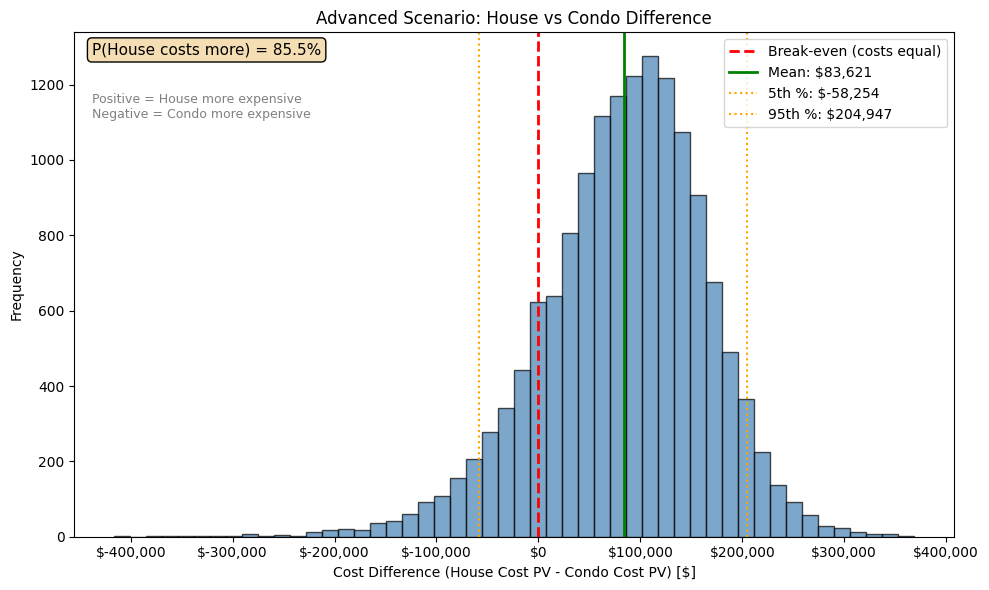

In [5]:
# Visualize the results
fig = plot_diff_distribution(mc_result, title="Advanced Scenario: House vs Condo Difference")
plt.show()

## 3. Multi-Scenario Comparison (Flat Rates)

Let's compare three scenarios with **flat** maintenance rates (not age-based curves).

**Note**: The full analysis above uses the age-based `maintenance_curve` from the config file (0.7% → 1.8% over 30 years), which results in ~85% P(House costs more). Here we compare flat rates to show sensitivity to the maintenance assumption.

We use conservative rates (0.5%-1.2%) because major expenses like roof replacement, HVAC, etc. are modeled as separate events. This avoids double-counting those costs.

In [13]:
# Define scenarios by modifying the house maintenance rate
# Note: Using conservative rates (0.5%-1.2%) since major events are modeled separately
#
# IMPORTANT: When maintenance_curve is set (as in advanced_config.yaml), it overrides 
# annual_maintenance_rate with age-based interpolation. To compare flat rate scenarios,
# we clear the curve and use only annual_maintenance_rate.

scenarios = {
    "optimistic": 0.005,  # 0.5% maintenance
    "base": 0.008,        # 0.8% maintenance (default)
    "pessimistic": 0.012, # 1.2% maintenance
}

results = {}

for name, maint_rate in scenarios.items():
    # Create modified house params with FLAT maintenance rate (no curve)
    house_mod = HouseParams(
        initial_value=house.initial_value,
        value_growth_rate=house.value_growth_rate,
        annual_maintenance_rate=maint_rate,
        events=house.events,
        other_recurring_costs=house.other_recurring_costs,
        maintenance_curve=[],  # Clear curve to use flat rate
    )
    
    # Run Monte Carlo
    mc = run_monte_carlo(condo, house_mod, sim, econ)
    results[name] = mc
    
    # Calculate monthly savings difference
    diff_monthly = pv_to_monthly_savings(abs(mc.diff_summary.mean), sim.discount_rate, sim.years)
    
    print(f"{name.upper()} (maint={maint_rate:.1%}):")
    print(f"  Mean cost diff (PV): ${mc.diff_summary.mean:,.0f}")
    print(f"  Extra monthly for house: ~${diff_monthly:,.0f}/mo")
    print(f"  P(House costs more): {mc.prob_house_more_expensive:.1%}")
    print()

OPTIMISTIC (maint=0.5%):
  Mean cost diff (PV): $-71,623
  Extra monthly for house: ~$322/mo
  P(House costs more): 16.4%

BASE (maint=0.8%):
  Mean cost diff (PV): $-12,755
  Extra monthly for house: ~$57/mo
  P(House costs more): 47.3%

PESSIMISTIC (maint=1.2%):
  Mean cost diff (PV): $65,735
  Extra monthly for house: ~$295/mo
  P(House costs more): 80.9%



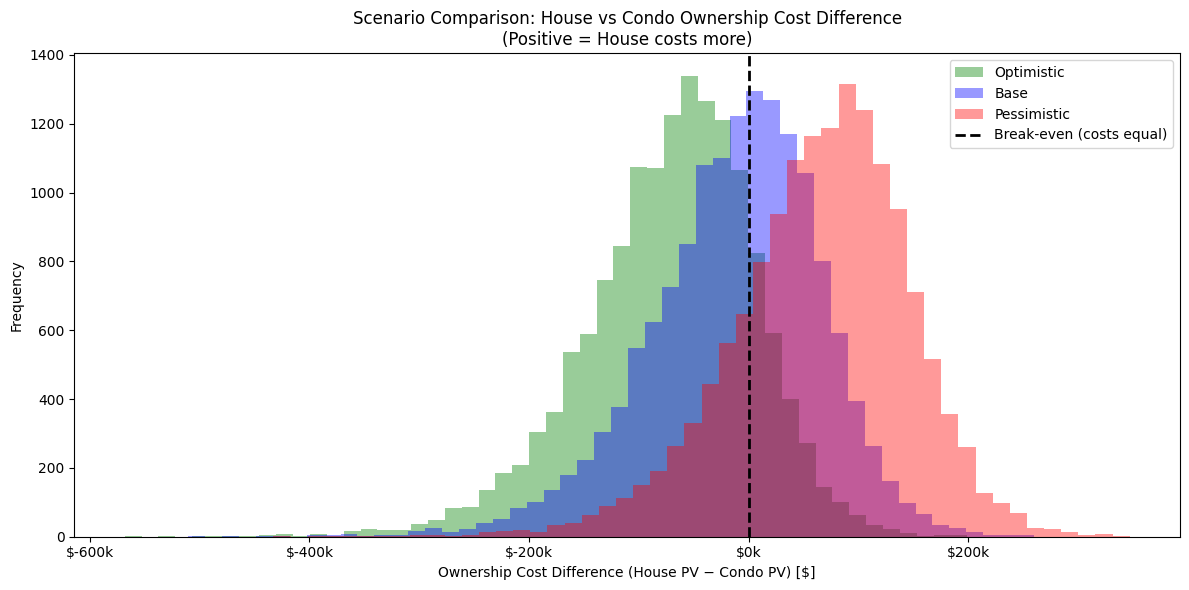

In [14]:
# Compare distributions
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'optimistic': 'green', 'base': 'blue', 'pessimistic': 'red'}

for name, mc in results.items():
    ax.hist(mc.diff_pv, bins=50, alpha=0.4, label=f"{name.capitalize()}", color=colors[name])

ax.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Break-even (costs equal)')
ax.set_xlabel('Ownership Cost Difference (House PV − Condo PV) [$]')
ax.set_ylabel('Frequency')
ax.set_title('Scenario Comparison: House vs Condo Ownership Cost Difference\n(Positive = House costs more)')
ax.legend()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()

## 4. Sensitivity Analysis

Let's see how the probability of house costing more changes as we vary key parameters.

Note: In this scenario, the house is substantially more expensive than the condo, so the probability stays at ~100% across different discount rates and horizons. This is expected behavior - it shows the conclusion is robust to these parameter choices.

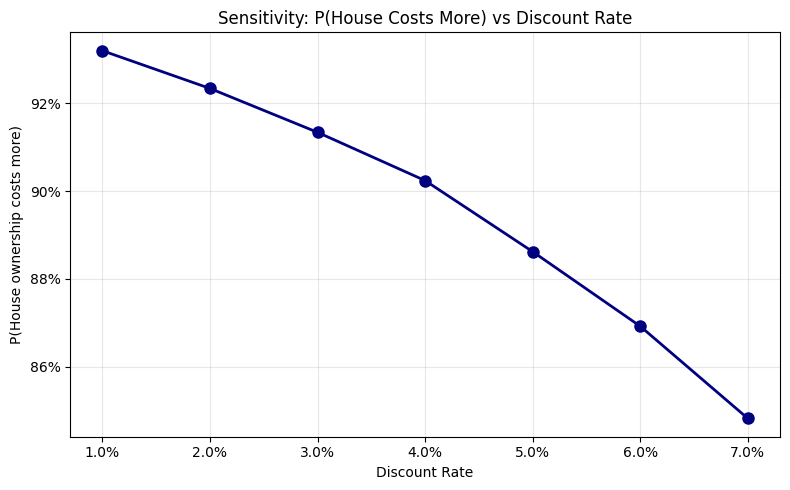

In [8]:
# Sensitivity to discount rate
discount_rates = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]
probs_by_rate = []

for rate in discount_rates:
    sim_mod = SimulationParams(
        years=sim.years,
        discount_rate=rate,
        num_sims=5000,  # Fewer sims for speed
        random_seed=sim.random_seed,
        house_maintenance_vol=sim.house_maintenance_vol,
        condo_fee_vol=sim.condo_fee_vol,
    )
    mc = run_monte_carlo(condo, house, sim_mod, econ)
    probs_by_rate.append(mc.prob_house_more_expensive)

# Plot
fig = plot_sensitivity(
    discount_rates, 
    probs_by_rate, 
    param_name="Discount Rate",
    title="Sensitivity: P(House Costs More) vs Discount Rate"
)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
plt.show()

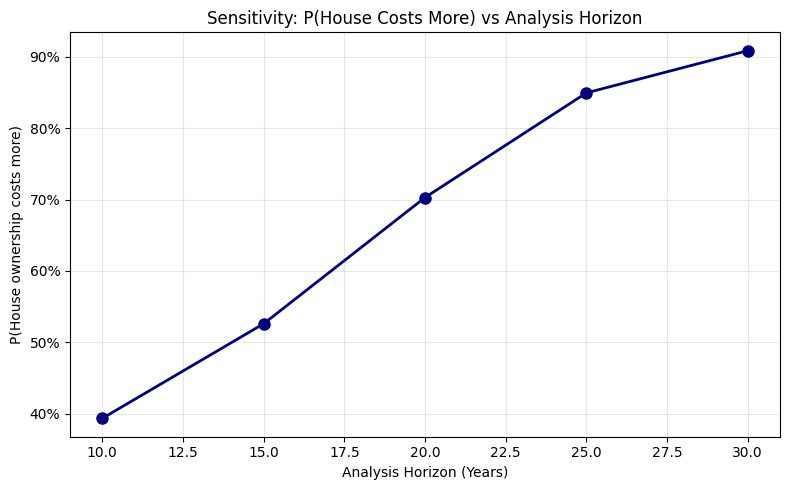

In [9]:
# Sensitivity to analysis horizon
year_values = [10, 15, 20, 25, 30]
probs_by_years = []

for years in year_values:
    sim_mod = SimulationParams(
        years=years,
        discount_rate=sim.discount_rate,
        num_sims=5000,
        random_seed=sim.random_seed,
        house_maintenance_vol=sim.house_maintenance_vol,
        condo_fee_vol=sim.condo_fee_vol,
    )
    mc = run_monte_carlo(condo, house, sim_mod, econ)
    probs_by_years.append(mc.prob_house_more_expensive)

# Plot
fig = plot_sensitivity(
    year_values, 
    probs_by_years, 
    param_name="Analysis Horizon (Years)",
    title="Sensitivity: P(House Costs More) vs Analysis Horizon"
)
plt.show()

## 5. Analyzing Event Timing

Let's examine how random event timing affects the ownership costs.

In [10]:
# Create a scenario with a single large event to isolate timing effects
house_single_event = HouseParams(
    initial_value=400_000,
    annual_maintenance_rate=0.005,  # Low routine maintenance
    events=[
        EventConfig(
            name="major_renovation",
            base_cost=30_000,
            expected_year=15,
            timing_std_years=4,  # Large timing uncertainty
            min_year=5,
            max_year=25,
            cost_vol=0.0,  # No cost uncertainty (isolate timing)
        ),
    ],
)

simple_condo = CondoParams(monthly_fee=300)

sim_timing = SimulationParams(
    years=25,
    discount_rate=0.04,
    num_sims=10_000,
    random_seed=123,
)

mc_timing = run_monte_carlo(simple_condo, house_single_event, sim_timing, econ)

# Calculate monthly equivalents
house_monthly = pv_to_monthly_savings(mc_timing.house_summary.mean, sim_timing.discount_rate, sim_timing.years)

print("Effect of timing uncertainty on a single $30k event:")
print(f"  Expected year: 15 (±4 years)")
print(f"\nHouse Ownership Cost PV:")
print(f"  Mean:  ${mc_timing.house_summary.mean:,.0f}  (~${house_monthly:,.0f}/mo)")
print(f"  Std:   ${mc_timing.house_summary.std:,.0f}")
print(f"  Range: [${mc_timing.house_summary.p5:,.0f}, ${mc_timing.house_summary.p95:,.0f}]")
print(f"\nThe timing uncertainty creates ~${mc_timing.house_summary.std:,.0f} PV variation")

Effect of timing uncertainty on a single $30k event:
  Expected year: 15 (±4 years)

House Ownership Cost PV:
  Mean:  $57,422  (~$303/mo)
  Std:   $2,820
  Range: [$53,087, $62,310]

The timing uncertainty creates ~$2,820 PV variation


## 6. Create Summary DataFrame

Let's create a summary with monthly savings equivalents.

In [11]:
# Create a comprehensive summary DataFrame
summary_data = []

for name, mc in results.items():
    condo_monthly = pv_to_monthly_savings(mc.condo_summary.mean, sim.discount_rate, sim.years)
    house_monthly = pv_to_monthly_savings(mc.house_summary.mean, sim.discount_rate, sim.years)
    diff_monthly = pv_to_monthly_savings(abs(mc.diff_summary.mean), sim.discount_rate, sim.years)
    
    summary_data.append({
        'Scenario': name.capitalize(),
        'Condo Cost PV': mc.condo_summary.mean,
        'Condo $/mo': condo_monthly,
        'House Cost PV': mc.house_summary.mean,
        'House $/mo': house_monthly,
        'Diff PV': mc.diff_summary.mean,
        'Extra $/mo': diff_monthly,
        'P(House>Condo)': mc.prob_house_more_expensive,
    })

summary_df = pd.DataFrame(summary_data)

# Format for display
display_df = summary_df.copy()
for col in ['Condo Cost PV', 'House Cost PV', 'Diff PV']:
    display_df[col] = display_df[col].apply(lambda x: f'${x:,.0f}')
for col in ['Condo $/mo', 'House $/mo', 'Extra $/mo']:
    display_df[col] = display_df[col].apply(lambda x: f'${x:,.0f}')
display_df['P(House>Condo)'] = display_df['P(House>Condo)'].apply(lambda x: f'{x:.1%}')

display_df

,Scenario,Condo Cost PV,Condo $/mo,House Cost PV,House $/mo,Diff PV,Extra $/mo,P(House>Condo)
0,Optimistic,"$274,439","$1,232","$202,817",$911,"$-71,623",$322,16.4%
1,Base,"$274,439","$1,232","$261,684","$1,175","$-12,755",$57,47.3%
2,Pessimistic,"$274,439","$1,232","$340,175","$1,528","$65,735",$295,80.9%


## Summary

This notebook demonstrated:

1. **YAML Configuration**: Load complex scenarios from files (nominal mode, inflation vol, reserves)
2. **Correlated Shocks**: Inflation-linked lognormal shocks for fees, maintenance, other costs, and events
3. **Multi-scenario Analysis**: Compare optimistic/base/pessimistic cases
4. **Sensitivity Analysis**: See how results change with discount rate and horizon
5. **Event Timing**: Hazard vs jitter timing with fat-tailed costs
6. **Monthly Savings**: Translate PV costs into actionable monthly amounts
